In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
from datetime import datetime, timedelta

tickers = ['MSFT', 'VTI', 'VXUS']
weights = {'VTI': 0.8, 'VXUS': 0.2}

CACHE_DIR = "cache_yf"
os.makedirs(CACHE_DIR, exist_ok=True)

end_date = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=365)).strftime('%Y-%m-%d')

def load_ticker(ticker, start, end):
    cache_path = os.path.join(CACHE_DIR, f"{ticker}.pkl")
    cached = None
    if os.path.exists(cache_path):
        cached = pd.read_pickle(cache_path)
        cached_start = cached.index.min().strftime('%Y-%m-%d')
        cached_end = cached.index.max().strftime('%Y-%m-%d')
        if cached_start <= start and cached_end >= end:
            print(f"  {ticker}: cached ({cached_start} to {cached_end})")
            return cached.loc[start:end]

    dl_start = start if cached is None else min(start, cached.index.min().strftime('%Y-%m-%d'))
    for attempt in range(3):
        try:
            df = yf.download(ticker, start=dl_start, end=end, progress=False)
            if not df.empty:
                close = df['Close']
                if isinstance(close, pd.DataFrame):
                    close = close.squeeze()
                if cached is not None:
                    close = pd.concat([cached, close])
                    close = close[~close.index.duplicated(keep='last')].sort_index()
                close.to_pickle(cache_path)
                print(f"  {ticker}: downloaded & cached ({close.index.min().date()} to {close.index.max().date()})")
                return close.loc[start:end]
        except Exception as e:
            print(f"  {ticker}: attempt {attempt+1} failed ({e})")
        time.sleep(5 * (attempt + 1))
    print(f"  {ticker}: FAILED after 3 attempts")
    if cached is not None:
        print(f"  {ticker}: using stale cache")
        return cached.loc[start:end]
    return None

print(f"Loading data ({start_date} to {end_date})...")
frames = {}
for ticker in tickers:
    series = load_ticker(ticker, start_date, end_date)
    if series is not None and not series.empty:
        frames[ticker] = series
    time.sleep(1)

if not frames:
    raise RuntimeError("No data available. Check network or ticker symbols.")
data = pd.DataFrame(frames)
print(f"Data shape: {data.shape}, date range: {data.index.min().date()} to {data.index.max().date()}")

Loading data (2025-04-16 to 2026-04-16)...
  MSFT: downloaded & cached (2025-04-16 to 2026-04-15)
  VTI: downloaded & cached (2025-04-16 to 2026-04-15)
  VXUS: downloaded & cached (2025-04-16 to 2026-04-15)
Data shape: (250, 3), date range: 2025-04-16 to 2026-04-15


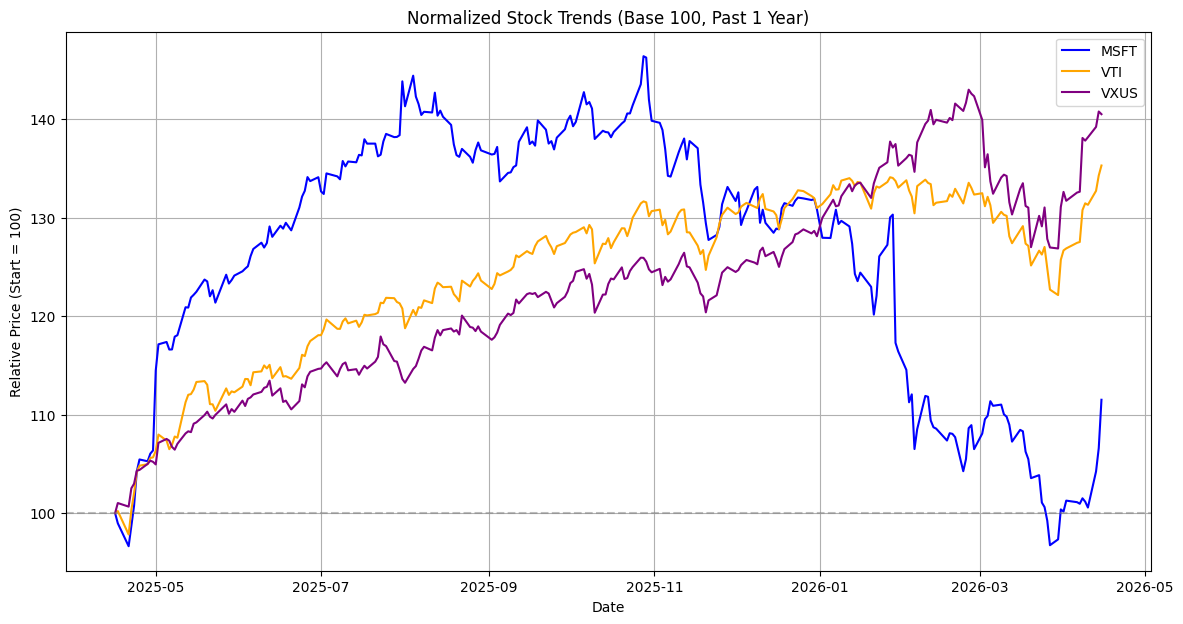

In [ ]:
data['Weighted_VTI_VXUS'] = data['VTI'] * weights['VTI'] + data['VXUS'] * weights['VXUS']
data['Exchange_Rate_MSFT'] = data['MSFT'] / data['Weighted_VTI_VXUS']
plt.figure(figsize=(14, 7))
for ticker, color in [('MSFT', 'blue'), ('VTI', 'orange'), ('VXUS', 'purple')]:
    normalized = data[ticker] / data[ticker].iloc[0] * 100
    plt.plot(normalized, label=ticker, color=color)
plt.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
plt.title('Normalized Stock Trends (Base 100, Past 1 Year)')
plt.xlabel('Date')
plt.ylabel('Relative Price (Start = 100)')
plt.legend()
plt.grid()
plt.show()

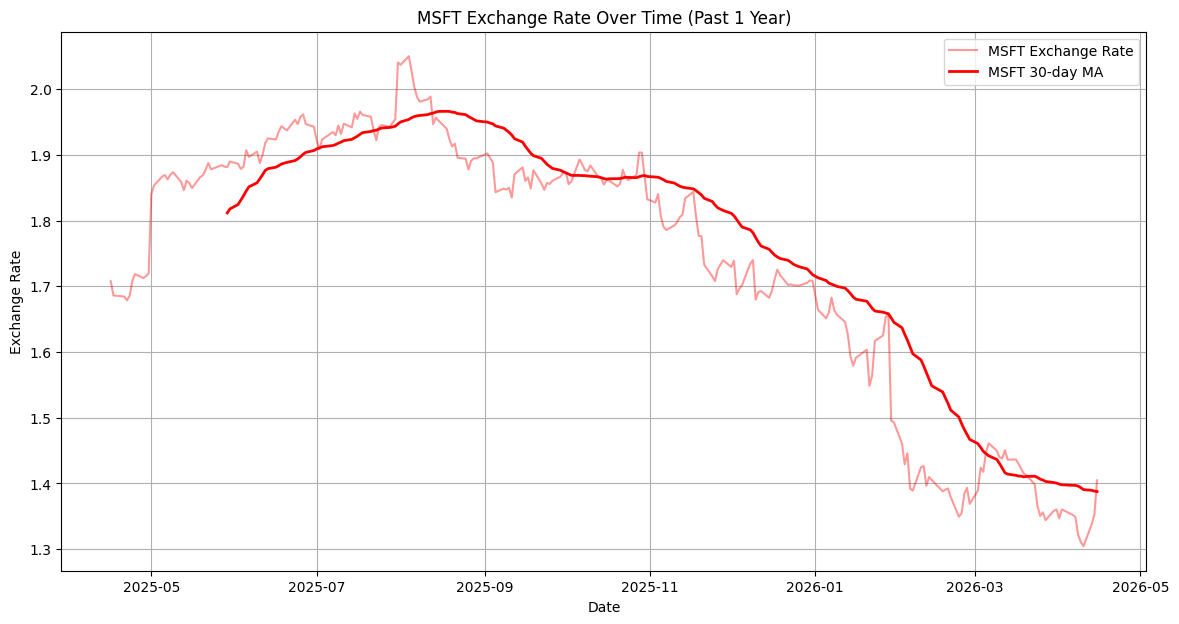

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(data['Exchange_Rate_MSFT'], label='MSFT Exchange Rate', color='red', alpha=0.4)
plt.plot(data['Exchange_Rate_MSFT'].rolling(30).mean(), label='MSFT 30-day MA', color='red', linewidth=2)
plt.title('MSFT Exchange Rate Over Time (Past 1 Year)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid()
plt.show()

In [ ]:
col = 'Exchange_Rate_MSFT'
best_date = data[col].idxmax()
best_val = data[col].max()
current_val = data[col].iloc[-1]
percentile = (data[col] < current_val).mean() * 100

print(f"--- MSFT (Past 1 Year) ---")
print(f"  Best rate:    {best_val:.2f} on {best_date.date()}")
print(f"  Current rate: {current_val:.2f} (higher than {percentile:.0f}% of past year)")
print(f"  Current vs best: {current_val / best_val * 100:.1f}%")
print()

rolling = data[col].rolling(30).mean().dropna()
top5 = rolling.nlargest(5)
print(f"  Top 5 best 30-day average periods:")
for date, val in top5.items():
    print(f"    {date.date()}: {val:.2f}")

--- MSFT (Past 1 Year) ---
  Best rate:    2.05 on 2025-08-04
  Current rate: 1.40 (higher than 12% of past year)
  Current vs best: 68.5%

  Top 5 best 30-day average periods:
    2025-08-18: 1.97
    2025-08-15: 1.97
    2025-08-19: 1.97
    2025-08-14: 1.97
    2025-08-20: 1.97


=== Your Scenario (received MSFT ~2026-03-03) ===
  MSFT price at receipt: $403.93
  MSFT price now:        $411.22 (+1.8%)
  Exchange rate at receipt: 1.42
  Exchange rate now:        1.40 (-1.4%)

  If exchanged on 2026-03-03: 352.6 weighted VTI/VXUS units
  If exchange today:                347.8 weighted VTI/VXUS units
  Difference: -1.4%

  Exchange rate since receipt:
    Min:  1.30 on 2026-04-10
    Max:  1.46 on 2026-03-06
    Now:  1.40
    Avg:  1.39



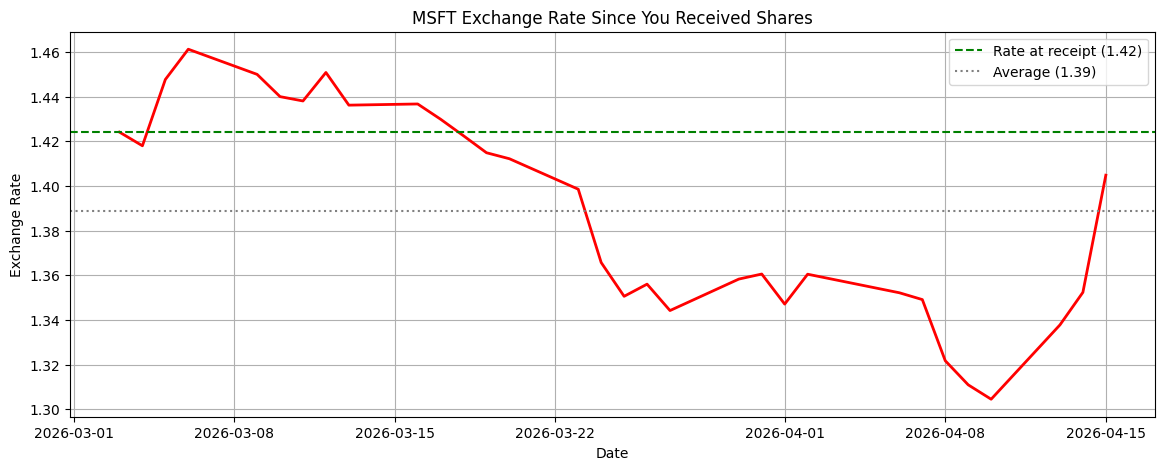

In [ ]:
received_date = '2026-03-03'
received_idx = data.index[data.index >= received_date][0]

msft_at_receipt = data['MSFT'].loc[received_idx]
rate_at_receipt = data['Exchange_Rate_MSFT'].loc[received_idx]
rate_now = data['Exchange_Rate_MSFT'].iloc[-1]
msft_now = data['MSFT'].iloc[-1]
vti_now = data['VTI'].iloc[-1]
vxus_now = data['VXUS'].iloc[-1]

print(f"=== Your Scenario (received MSFT ~{received_idx.date()}) ===")
print(f"  MSFT price at receipt: ${msft_at_receipt:.2f}")
print(f"  MSFT price now:        ${msft_now:.2f} ({(msft_now/msft_at_receipt - 1)*100:+.1f}%)")
print(f"  Exchange rate at receipt: {rate_at_receipt:.2f}")
print(f"  Exchange rate now:        {rate_now:.2f} ({(rate_now/rate_at_receipt - 1)*100:+.1f}%)")
print()

msft_value = 100000
shares_then = msft_value / (data['Weighted_VTI_VXUS'].loc[received_idx])
shares_now = msft_value * (msft_now / msft_at_receipt) / data['Weighted_VTI_VXUS'].iloc[-1]

print(f"  If exchanged on {received_idx.date()}: {shares_then:.1f} weighted VTI/VXUS units")
print(f"  If exchange today:                {shares_now:.1f} weighted VTI/VXUS units")
print(f"  Difference: {(shares_now/shares_then - 1)*100:+.1f}%")
print()

recent = data.loc[received_date:]
print(f"  Exchange rate since receipt:")
print(f"    Min:  {recent['Exchange_Rate_MSFT'].min():.2f} on {recent['Exchange_Rate_MSFT'].idxmin().date()}")
print(f"    Max:  {recent['Exchange_Rate_MSFT'].max():.2f} on {recent['Exchange_Rate_MSFT'].idxmax().date()}")
print(f"    Now:  {rate_now:.2f}")
print(f"    Avg:  {recent['Exchange_Rate_MSFT'].mean():.2f}")
print()

plt.figure(figsize=(14, 5))
plt.plot(recent['Exchange_Rate_MSFT'], color='red', linewidth=2)
plt.axhline(y=rate_at_receipt, color='green', linestyle='--', label=f'Rate at receipt ({rate_at_receipt:.2f})')
plt.axhline(y=recent['Exchange_Rate_MSFT'].mean(), color='gray', linestyle=':', label=f'Average ({recent["Exchange_Rate_MSFT"].mean():.2f})')
plt.title('MSFT Exchange Rate Since You Received Shares')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid()
plt.show()